# Comment Category Prediction — Complete ML Pipeline
**Kaggle Project | MLP - IITM DS**

# 1) Importing Necessary Libraries

In [1]:
import re
import torch
import string
from scipy.sparse import hstack, csr_matrix
from scipy.stats import randint, uniform, loguniform

#EDA
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

#Pre-processing and Feature Engineering 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler,
                                   MinMaxScaler,
                                   OneHotEncoder,
                                   LabelEncoder)
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV,KFold
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

#models
from sklearn.dummy import DummyClassifier 
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import TruncatedSVD
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb

# For warnings
import warnings
warnings.filterwarnings('ignore')

# For class balance 
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import compute_sample_weight

print('All libraries imported successfully!')

2026-04-02 04:28:43.006352: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775104123.262672      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775104123.342081      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775104123.947920      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775104123.947972      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775104123.947975      55 computation_placer.cc:177] computation placer alr

All libraries imported successfully!


# 2) Data Loading

In [2]:
# Load data
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

In [3]:
print('=== First 5 rows of training data ===')
train.tail()

=== First 5 rows of training data ===


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
197995,2023-02-04 10:39:30.581185+00:00,39,0,0,0,2,0,0,4,NaN,NaN,NaN,False,Why save people who are bent on self-destructi...,0
197996,2023-11-01 17:16:51.337370+00:00,72,0,0,0,1,0,0,10,NaN,NaN,NaN,False,Trudeau is not only undemocratic but also innu...,2
197997,2024-03-09 15:46:22.542539+00:00,72,0,0,0,0,0,0,10,NaN,NaN,NaN,False,block all exports no humanitarian relief and a...,3
197998,2023-08-07 17:23:40.163756+00:00,72,0,1,1,5,7,4,10,black,none,none,False,really black kids seeing that is better than g...,1
197999,2023-08-26 19:36:00.380158+00:00,72,0,0,0,1,0,4,4,none,none,none,False,"Sounds likely since: ""But now scientists have ...",0


### Column Descriptions

| Column | Type | Description |
|--------|------|-------------|
| `comment` | text | Raw text content of the comment |
| `created_date` | datetime | Timestamp when comment was posted |
| `post_id` | int | Links comment to its parent discussion thread |
| `emoticon_1/2/3` | int | Presence indicator for three internal emoticon groups |
| `upvote` | int | Count of positive reactions received |
| `downvote` | int | Count of negative reactions received |
| `if_1` | int | Internal hidden platform signal 1 |
| `if_2` | int | Internal hidden platform signal 2 |
| `race` | str | Detected group-identity reference (NaN = not detected) |
| `religion` | str | Detected belief-topic reference |
| `gender` | str | Detected gender-topic reference |
| `disability` | bool | Detected ability-related reference |
| `label` | int | **Target variable** — 4 classes (0, 1, 2, 3) |


In [4]:
print('Train data shape:',train.shape)
print('Test data shape:',test.shape)

Train data shape: (198000, 15)
Test data shape: (102000, 14)


# 3) Data Types Identification

In [5]:
# This helps us immediately spot:
#   - Missing values (non-null count < total rows)
#   - Incorrect dtypes (e.g. a numeric column stored as 'object')
train.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [6]:
print('1) object type= ',train.select_dtypes(include='object').columns.tolist())
print('2) int type= ',train.select_dtypes(include='int64').columns.tolist())
print('3) bool type= ',train.select_dtypes(include='bool').columns.tolist())

1) object type=  ['created_date', 'race', 'religion', 'gender', 'comment']
2) int type=  ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'label']
3) bool type=  ['disability']


# 4) Identifying Missing Values

In [7]:
# Missing values must be handled BEFORE model training (models crash on NaN)
print('=== Missing values in TRAIN set ===')
missing_train = train.isna().sum()
missing_pct   = (train.isna().mean() * 100).round(2)
missing_df    = pd.DataFrame({'Count': missing_train, 'Percentage %': missing_pct})
missing_df    = missing_df[missing_df['Count'] > 0]  # show only columns with NaN
print(missing_df if len(missing_df) else 'No missing values in train!')

print('\n=== Missing values in TEST set ===')
missing_test = test.isna().sum()
missing_test_pct = (test.isna().mean() * 100).round(2)
missing_test_df  = pd.DataFrame({'Count': missing_test, 'Percentage %': missing_test_pct})
missing_test_df  = missing_test_df[missing_test_df['Count'] > 0]
print(missing_test_df if len(missing_test_df) else 'No missing values in test!')

=== Missing values in TRAIN set ===
           Count  Percentage %
race      145423         73.45
religion  145423         73.45
gender    145423         73.45
comment        1          0.00

=== Missing values in TEST set ===
          Count  Percentage %
race      75269         73.79
religion  75269         73.79
gender    75269         73.79


#### Imputation Strategy

- `race`, `religion`, `gender` → NaN means **not detected** → fill with `"none"` (meaningful category)
- `comment` → NaN means **empty post** → fill with `""`
- `upvote`, `downvote` → NaN means **zero votes** → fill with `0`

> All imputation handled inside **sklearn Pipelines** in the preprocessing step.

# 5) Handling Duplicates

In [8]:
n_dupes = train.duplicated().sum()
print(f'No. of duplicates found: {n_dupes}')
print(f"Original training data shape: {train.shape}")
if n_dupes > 0:
    train.drop_duplicates(inplace=True)
    train.reset_index(drop=True, inplace=True)  # re-index after row removal
    print(f'Training set shape AFTER  removing duplicates: {train.shape}')
else:
    print('No duplicates found — no action required.')

No. of duplicates found: 0
Original training data shape: (198000, 15)
No duplicates found — no action required.


# 6) Descriptive Statistics

In [9]:
desc = train.describe().rename(index={'50%': 'median'})
print('=== Descriptive Statistics (numeric columns) ===')
desc.T

=== Descriptive Statistics (numeric columns) ===


,count,mean,std,min,25%,median,75%,max
post_id,198000.0,68.447429,27.948390,20.0,39.0,72.0,72.0,129.0
emoticon_1,198000.0,0.279768,1.023234,0.0,0.0,0.0,0.0,47.0
emoticon_2,198000.0,0.048338,0.258477,0.0,0.0,0.0,0.0,11.0
emoticon_3,198000.0,0.121071,0.481013,0.0,0.0,0.0,0.0,17.0
upvote,198000.0,2.607975,5.054763,0.0,0.0,1.0,3.0,201.0
downvote,198000.0,0.666394,2.044335,0.0,0.0,0.0,1.0,107.0
if_1,198000.0,1.906152,25.635752,0.0,0.0,0.0,4.0,1860.0
if_2,198000.0,7.956212,14.839464,3.0,4.0,6.0,10.0,1833.0
label,198000.0,0.793965,0.979808,0.0,0.0,0.0,2.0,3.0


### Key Insights

- **198,000 comments** with no missing values in numeric columns → clean dataset ready for modeling.
- **Label is heavily imbalanced** (mean ≈ 0.79, median = 0) → majority are class 0; should use class weights or stratified splits.
- **Upvotes & downvotes are right-skewed** (means ~2.6 and ~0.67, but maxes of 201 and 107) → log-transform before modeling; downvotes may correlate with toxicity.
- **Emoticons are sparse** (all medians = 0, low means) → consider binary encoding (present/absent) instead of raw counts.
- **if_1 is highly skewed** (mean ~1.9 but max 1860) → likely a rare viral/flagging signal; needs capping or log-transform.
- **if_2 is more stable** (mean ~8, median 6) → may carry more consistent predictive signal than if_1.

In [10]:
engagement_summary = train.groupby("label").agg({
    "upvote": ["mean", "median", "std"],
    "downvote": ["mean", "median", "std"]
})
print('=== Engagement Statistics by Label ===')
engagement_summary 

=== Engagement Statistics by Label ===


upvote                   downvote                 
           mean median       std      mean median       std
label                                                      
0      2.404833    1.0  4.601209  0.575294    0.0  1.863328
1      2.850107    1.0  6.047758  0.802048    0.0  2.171240
2      2.967825    1.0  5.612198  0.811723    0.0  2.336218
3      2.035656    1.0  3.765532  0.514171    0.0  1.517042

#### Engagement Statistics by Label — Key Insights

- **All labels share median upvote = 1 and median downvote = 0** → engagement alone is a weak separator between classes.
- **Labels 1 & 2 have slightly higher mean upvotes ~(2.85, 2.97) and downvotes ~(0.80, 0.81)** → mildly toxic content may attract more reactions overall.
- **Label 3 has the lowest engagement** (upvote mean ~2.04, downvote mean ~0.51) → most severe toxicity may get less interaction, possibly due to removal or user avoidance, or they are just meaningless spam category.
- **High std across all labels** relative to means → engagement is noisy and skewed; unlikely to be a strong standalone feature but may add marginal signal in tree-based models.

# 7) Handling Outliers

In [11]:
# # The IQR (Inter-Quartile Range) method defines outliers as values
# # below Q1 - 1.5*IQR  or  above Q3 + 1.5*IQR
# # We skip pure binary columns (only 0/1) since clipping them makes no sense

# print('OUTLIER DETECTION (IQR method)')
# print('=' * 50)

# outlier_report = {}

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# for col in ['upvote', 'downvote']:   # Most likely to have extreme outliers
#     Q1  = train[col].quantile(0.25)  
#     Q3  = train[col].quantile(0.75)  
#     IQR = Q3 - Q1                    
#     lower = Q1 - 1.5 * IQR          
#     upper = Q3 + 1.5 * IQR          
#     n_out = ((train[col] < lower) | (train[col] > upper)).sum()
#     outlier_report[col] = {'lower': round(lower, 2), 'upper': round(upper, 2), 'n_outliers': n_out}
#     print(f'{col}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}, bounds=[{lower:.1f}, {upper:.1f}], outliers={n_out}')

# # Visualise with boxplots
# sns.boxplot(data=train, y='upvote',   ax=axes[0], color='#3498db')
# axes[0].set_title('Upvote Distribution (before clipping)')
# sns.boxplot(data=train, y='downvote', ax=axes[1], color='#e74c3c')
# axes[1].set_title('Downvote Distribution (before clipping)')
# plt.tight_layout(); plt.show()

# # NOTE: We use clipping (capping at upper/lower bounds) rather than deletion
# # because these are engagement signals — extreme values still carry information
# # (a post with 10,000 upvotes is genuinely popular, just extreme)
# # Clipping preserves the row while reducing the influence of extreme values
# for col in ['upvote', 'downvote']:
#     lower = outlier_report[col]['lower']
#     upper = outlier_report[col]['upper']
#     train[col] = train[col].clip(lower=max(0, lower), upper=upper)
#     test[col]  = test[col].clip(lower=max(0, lower), upper=upper)
# print('\nOutliers clipped (capped at IQR bounds) in both train and test.')

NOTE: The outlier clipping cell in this notebook is more of a checklist item demonstration than a critical step. The real outlier mitigation happens through log-transformation in feature engineering and the tree model's natural robustness.

# 8) Data Visualisations (EDA)

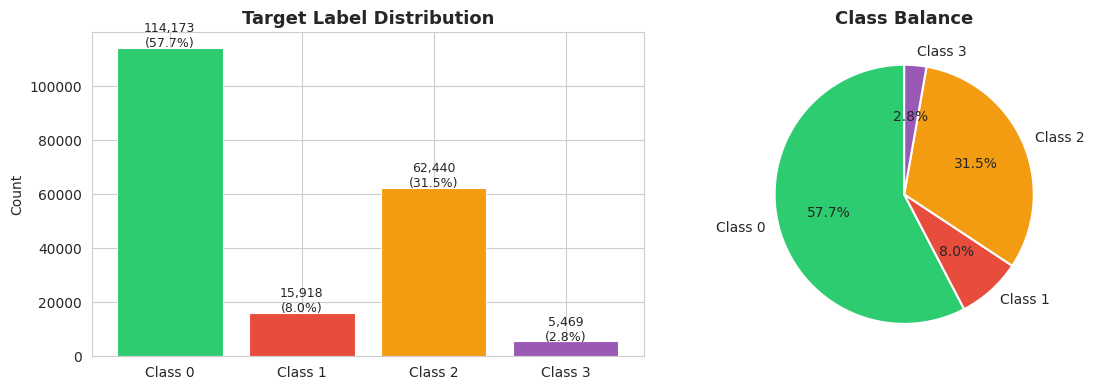

In [12]:
# ── PLOT 1: Target Distribution ──────────────────────────────────────────
# Understanding class balance is the FIRST thing to do in classification

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_counts = train['label'].value_counts().sort_index()
label_names  = {0: 'Class 0', 1: 'Class 1', 2: 'Class 2', 3: 'Class 3'}
colors       = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

# Bar chart: absolute counts + percentage labels on top of each bar
bars = axes[0].bar(
    [label_names[i] for i in label_counts.index],
     label_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Target Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}\n({val/len(train)*100:.1f}%)', ha='center', fontsize=9)

# Pie chart: proportional view
axes[1].pie(label_counts.values,
            labels=[label_names[i] for i in label_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.tight_layout(); plt.show()

### EDA INSIGHT 1 – CLASS IMBALANCE
============================================================ 

INSIGHT:
- Severe class imbalance present
- Class 0 (57.7%) and Class 2 (31.5%) dominate (~89% of dataset)
- Class 1 (8.0%) is underrepresented but still learnable
- Class 3 (2.8%) is extremely rare → hardest to predict
- Model will naturally bias toward Class 0 without correction

FEATURE ENGINEERING / MODELING ACTIONS:
- Use stratified split to preserve class distribution
- Apply class weights to penalize misclassification of minority classes
- Focus on creating highly discriminative features for Class 1 and Class 3
- Build strong interaction features to capture rare patterns
- Avoid relying on accuracy; optimize for Macro-F1
- Monitor per-class recall (especially Class 1 & 3)
- Consider probability calibration/threshold tuning to improve minority class recall

In [13]:
print(train['if_1'].value_counts().to_dict())
print(train['if_2'].value_counts().to_dict())

{0: 145423, 4: 31061, 10: 11849, 6: 6774, 5: 2691, 7: 70, 9: 45, 11: 32, 12: 2, 1814: 2, 1545: 2, 1783: 2, 8: 2, 1551: 2, 249: 1, 1569: 1, 1800: 1, 1560: 1, 1263: 1, 1267: 1, 1258: 1, 1543: 1, 250: 1, 1815: 1, 1538: 1, 1585: 1, 1830: 1, 1277: 1, 1807: 1, 1810: 1, 1777: 1, 1848: 1, 1257: 1, 1548: 1, 1232: 1, 1583: 1, 1572: 1, 1576: 1, 1256: 1, 1566: 1, 1547: 1, 1825: 1, 1271: 1, 1838: 1, 1553: 1, 1846: 1, 1558: 1, 1557: 1, 1767: 1, 1819: 1, 1581: 1, 1254: 1, 1811: 1, 1860: 1, 1778: 1, 1827: 1, 1584: 1}
{4: 91726, 10: 80693, 6: 14558, 5: 6188, 70: 453, 7: 366, 11: 312, 80: 286, 64: 281, 74: 238, 76: 213, 66: 208, 60: 186, 65: 163, 9: 157, 68: 156, 62: 136, 58: 131, 75: 126, 59: 107, 71: 106, 69: 104, 56: 78, 72: 76, 54: 75, 61: 75, 63: 70, 52: 65, 55: 60, 53: 59, 57: 54, 8: 44, 51: 37, 67: 34, 50: 34, 49: 34, 48: 27, 47: 25, 46: 21, 45: 20, 12: 18, 81: 18, 44: 17, 43: 15, 42: 14, 41: 14, 40: 13, 77: 13, 38: 10, 34: 10, 36: 9, 39: 8, 73: 7, 37: 7, 13: 5, 32: 5, 35: 4, 33: 3, 31: 3, 3: 3, 

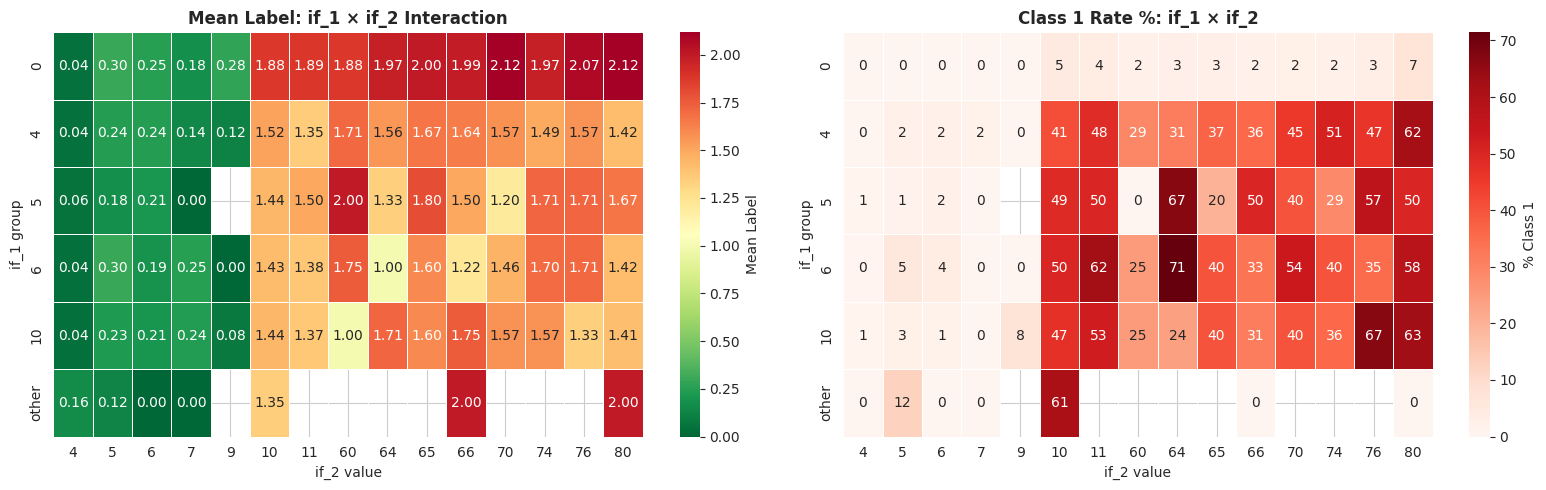

In [14]:
# ── PLOT 2: Internal Feature Interaction (if_1 × if_2) ───────────────────
# if_1 and if_2 are hidden platform signals — likely the most predictive features
# We use a heatmap to visualise how their combinations correlate with labels

train['if_1_grp'] = train['if_1'].apply(lambda x: x if x in [0, 4, 5, 6,10] else 'other')
common_if2 = train['if_2'].value_counts().head(15).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: mean label value per cell — shows which combos tend toward high/low labels
pivot_mean = (train[train['if_2'].isin(common_if2)]
              .groupby(['if_1_grp', 'if_2'])['label'].mean().unstack())
sns.heatmap(pivot_mean, annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=axes[0], linewidths=0.5, cbar_kws={'label': 'Mean Label'})
axes[0].set_title('Mean Label: if_1 × if_2 Interaction', fontweight='bold')
axes[0].set_xlabel('if_2 value'); axes[0].set_ylabel('if_1 group')

# Right: % of Class 1 per cell
# basically out of all comments with this (if_1, if_2) combination, what % are class 1?
pivot_c1 = (train[train['if_2'].isin(common_if2)]
            .groupby(['if_1_grp', 'if_2'])
            .apply(lambda x: (x['label'] == 1).sum() / len(x) * 100).unstack())
sns.heatmap(pivot_c1, annot=True, fmt='.0f', cmap='Reds',
            ax=axes[1], linewidths=0.5, cbar_kws={'label': '% Class 1'})
axes[1].set_title('Class 1 Rate %: if_1 × if_2', fontweight='bold')
axes[1].set_xlabel('if_2 value'); axes[1].set_ylabel('if_1 group')

plt.tight_layout(); plt.show()

### EDA INSIGHT 2 – 
### if_1 × if_2 INTERACTION
============================================================

INSIGHT:
- Strong interaction effect between if_1 and if_2 on target label
- Low if_2 values (4–7) → mostly Class 0 (very low mean label, near 0)
- High if_2 values (10, 11, 70, 80) → sharp increase in mean label (Class 1/2/3)
- Certain combinations (if_1 ∈ {0,4,10} with high if_2) show very high toxicity rates
- Class 1 (toxic) spikes heavily when if_2 ≥ 10 across multiple if_1 groups
- Interaction is more predictive than individual features alone

FEATURE ENGINEERING / MODELING ACTIONS:
- Treat if_1 and if_2 as categorical/binned features, not continuous
- Create detailed interaction features between if_1 and if_2 (not just binary flags)
    - Full cross: (if_1, if_2)
    - Zone-based: (if_2_low, if_2_high) × if_1
- Encode specific high-risk combinations (e.g., if_2 ≥ 10 with key if_1 values)
- Create bins for if_2 (low, mid, high) to capture sharp transitions
- Add cross-features (if_1 × if_2) to capture non-linear relationships
- Create "risk zones":
    - (if_1 ∈ {0,4,10}) & (if_2 ≥ 10)
- Consider target encoding or frequency encoding for (if_1, if_2) pairs
- Prioritize these interaction features as they are highly predictive


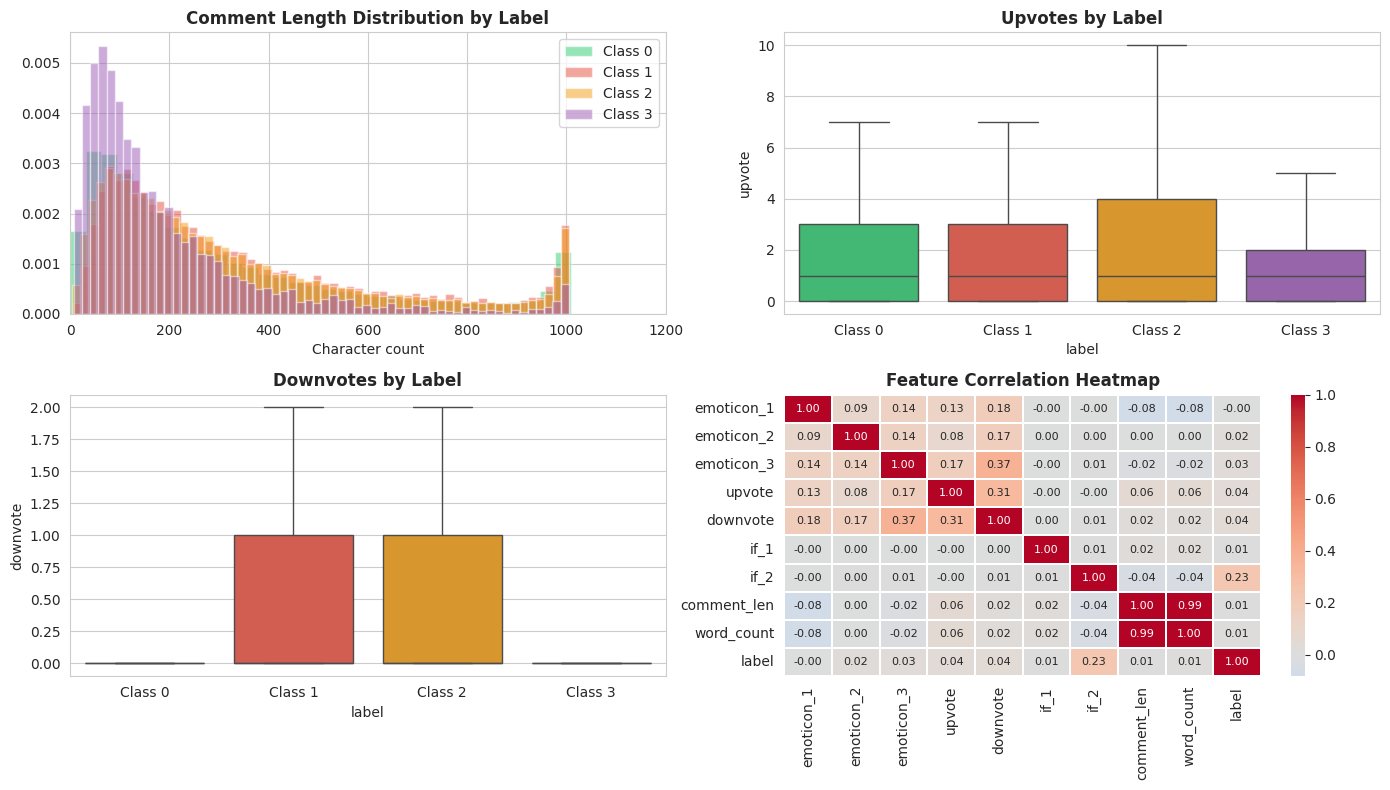

In [15]:
# ── PLOT 3: Comment Length, Upvotes, Downvotes, Correlations ─────────────
# Text length and engagement patterns often differ between toxic/non-toxic content

train['comment_len'] = train['comment'].fillna('').str.len()           
train['word_count']  = train['comment'].fillna('').str.split().str.len()  

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Overlapping histograms: comment length per class
for label_val, color in zip([0, 1, 2, 3], colors):
    subset = train[train['label'] == label_val]['comment_len']
    axes[0, 0].hist(subset, bins=60, alpha=0.5, color=color,
                    label=f'Class {label_val}', density=True)
axes[0, 0].set_title('Comment Length Distribution by Label', fontweight='bold')
axes[0, 0].set_xlabel('Character count'); axes[0, 0].set_xlim(0, 1200)
axes[0, 0].legend()

# Boxplot: upvotes per label 
sns.boxplot(data=train, x='label', y='upvote', palette=colors,
            ax=axes[0, 1], showfliers=False, linewidth=1)
axes[0, 1].set_title('Upvotes by Label', fontweight='bold')
axes[0, 1].set_xticklabels(['Class 0', 'Class 1', 'Class 2', 'Class 3'])

# Boxplot: downvotes per label
sns.boxplot(data=train, x='label', y='downvote', palette=colors,
            ax=axes[1, 0], showfliers=False, linewidth=1)
axes[1, 0].set_title('Downvotes by Label', fontweight='bold')
axes[1, 0].set_xticklabels(['Class 0', 'Class 1', 'Class 2', 'Class 3'])

# Correlation heatmap: Pearson correlation of numeric features with label
num_cols_corr = ['emoticon_1', 'emoticon_2', 'emoticon_3',
                 'upvote', 'downvote', 'if_1', 'if_2',
                 'comment_len', 'word_count', 'label']
corr = train[num_cols_corr].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[1, 1], linewidths=0.3, annot_kws={'size': 8})
axes[1, 1].set_title('Feature Correlation Heatmap', fontweight='bold')
plt.tight_layout(); plt.show()

### EDA INSIGHT 3 – 

### COMMENT LENGTH DISTRIBUTION
============================================================

INSIGHT:
- Highly right-skewed distribution (long tail up to ~1000 chars)
- Most comments are short (<200 chars)
- Class 3 (rare class) is concentrated in very short comments
- Class 2 appears more in longer comments (heavier tail)
- Overlap exists across classes → length alone is weak predictor
- Extreme long comments may carry structured or repeated patterns

FEATURE ENGINEERING / MODELING ACTIONS:
- Keep comment length, but do NOT rely on it as a primary feature
- Apply log transformation to reduce skew:
    → log_comment_len = log1p(comment_len)
- Create length buckets:
    → very_short, short, medium, long
- Capture extreme cases:
    → is_very_long (e.g., >800 chars)
- Combine with other features (e.g., sentiment, identity) for stronger signal
- Avoid assuming monotonic relationship with label

### VOTING BEHAVIOR (UPVOTES + DOWNVOTES)
============================================================

INSIGHT:
- Voting features capture community reaction rather than direct toxicity
- Upvotes show weak separation:
    → Class 2 tends to have higher upvotes (higher engagement/visibility)
    → Class 0 and Class 1 overlap heavily
- Downvotes are highly sparse (many zeros) but more informative:
    → Class 1 and Class 2 show higher presence of downvotes
    → Class 0 mostly has zero downvotes
- Indicates:
    → Upvotes ≈ popularity / agreement
    → Downvotes ≈ controversy / toxicity signal
- Distribution is skewed and zero-inflated → raw counts are less reliable
- Relative measures (ratios/differences) are more informative than absolute values

FEATURE ENGINEERING / MODELING ACTIONS:
- Use log transformation for skewed counts:
    → log_upvote, log_downvote
- Prioritize relative features:
    → vote_diff (net sentiment)
    → vote_ratio (normalized approval)
    → controversy (fraction of downvotes)
- Binary signals are highly useful:
    → has_downvote (strong indicator)
- Add threshold-based feature:
    → high_downvote (e.g., downvote ≥ 2)
- Avoid relying on raw upvote/downvote counts alone
- Combine voting features with other signals (text, identity, if_1 × if_2)
- Treat voting features as supporting features, not primary drivers

### FEATURE CORRELATION
============================================================

INSIGHT:
- comment_len and word_count are almost perfectly correlated (~0.99)
    → redundant features (multicollinearity risk for linear models)
- emoticon_3 has strongest correlation with Downvote (~0.37)
    → could be an informative combo
- upvote and downvote moderately correlated (~0.31)
    → expected (engagement signal)
- if_1 shows near-zero linear correlation with label while if_2 still has some linear correlation(~0.23)
    → BUT earlier EDA shows strong NON-LINEAR interaction
    → confirms need for interaction features
- Most features individually have weak linear correlation with label
    → problem is highly non-linear

FEATURE ENGINEERING / MODELING ACTIONS:
- Drop one of:
    → comment_len OR word_count (keep both only for tree models)
- Keep emoticon features (especially emoticon_3)
- Do NOT rely on correlation to judge importance of if_1 / if_2
- Focus on:
    → interaction features
    → non-linear transformations
- Prefer tree-based models (LightGBM / XGBoost)

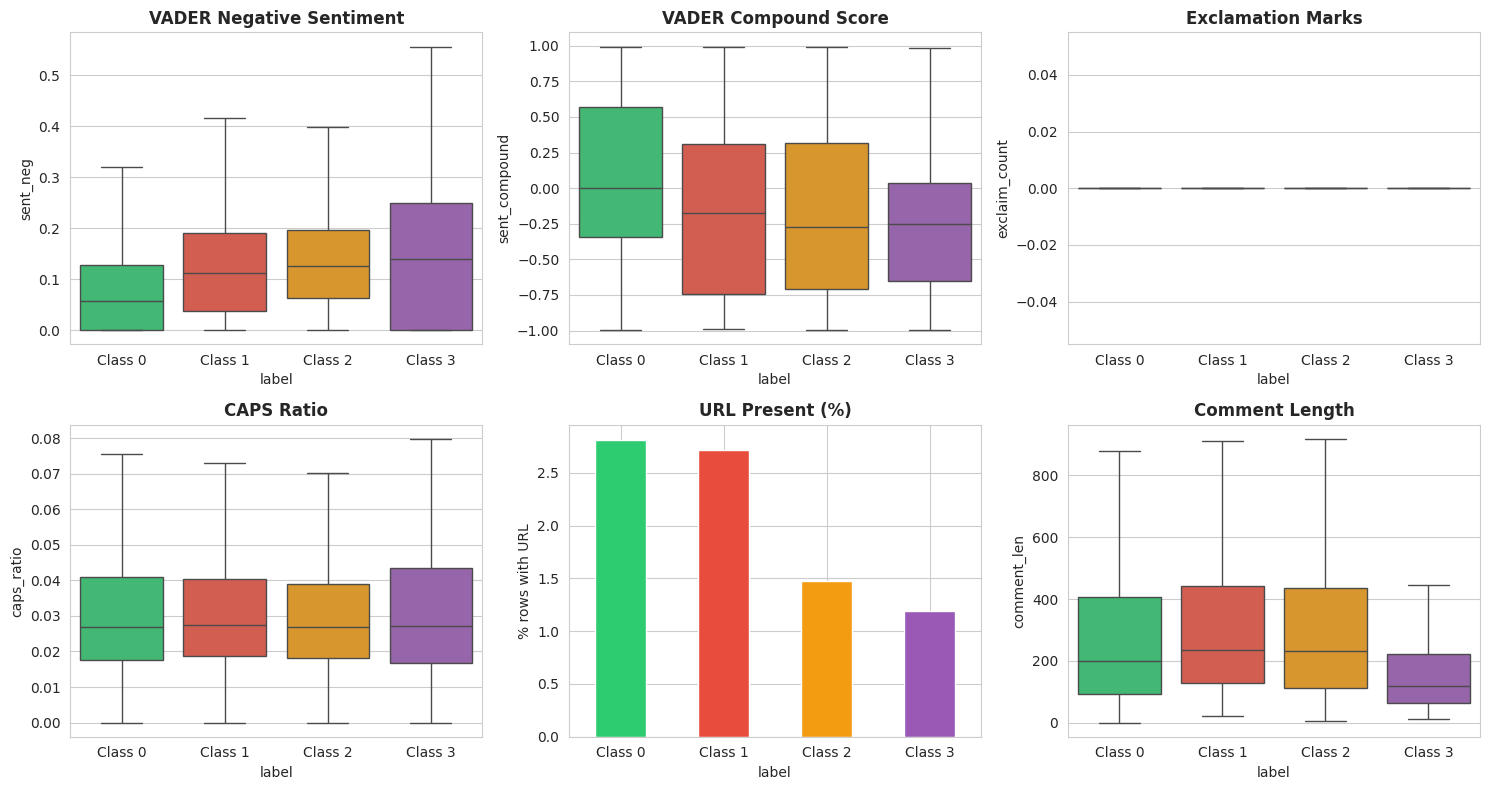

In [16]:
# ── PLOT 4: VADER Sentiment & Text Style Signals ─────────────────────────
# Toxic comments are expected to have higher negative sentiment scores
# We sample 10,000 rows for speed (VADER is slow on large corpora)

nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

# Sample for computational speed
sample = train.sample(10000, random_state=42).copy()
sample['comment'] = sample['comment'].fillna('')

# Apply VADER to each comment — returns dict with neg/neu/pos/compound
scores = sample['comment'].apply(lambda x: sia.polarity_scores(x))
sample['sent_neg']      = scores.apply(lambda x: x['neg'])      
sample['sent_compound'] = scores.apply(lambda x: x['compound']) 
sample['exclaim_count'] = sample['comment'].str.count('!')
sample['caps_ratio']    = sample['comment'].apply(
    lambda x: sum(1 for c in x if c.isupper())/(len(x)+1))
sample['url_present']   = sample['comment'].str.contains(
    r'http[s]?://', regex=True).astype(int)
sample['comment_len'] = sample['comment'].apply(len)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features = ['sent_neg', 'sent_compound', 'exclaim_count', 'caps_ratio', 'url_present', 'comment_len']
titles   = ['VADER Negative Sentiment', 'VADER Compound Score',
             'Exclamation Marks', 'CAPS Ratio', 'URL Present (%)', 'Comment Length']

for ax, feat, title in zip(axes.flat, features, titles):
    if feat == 'url_present':
        # Bar chart: % of comments with URL per class
        url_by_label = sample.groupby('label')['url_present'].mean() * 100
        url_by_label.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
        ax.set_title(f'{title}', fontweight='bold')
        ax.set_xticklabels(['Class 0','Class 1','Class 2','Class 3'], rotation=0)
        ax.set_ylabel('% rows with URL')
    else:
        # Boxplot: distribution of feature per class
        sns.boxplot(data=sample, x='label', y=feat, palette=colors, 
                    ax=ax, showfliers=False, linewidth=1)
        ax.set_title(title, fontweight='bold')
        ax.set_xticklabels(['Class 0','Class 1','Class 2','Class 3'])

plt.tight_layout()
plt.show()

### EDA INSIGHT 4– TEXT + SENTIMENT + STYLE FEATURES
============================================================

INSIGHT:
- VADER Sentiment:
  - Negative sentiment increases from Class 0 → Class 3
  - Class 3 shows highest negativity → strong toxicity indicator
  - Compound score shifts from most positive for Class 0 to negative (Class 1/2/3)
  - Sentiment is a strong directional signal for classification  
- Exclamation Marks:
  - Almost no variation across classes
  - Very low counts → weak / non-informative feature  
- CAPS Ratio:
  - Slightly higher for toxic classes (Class 1/3), but heavy overlap
  - Weak standalone predictor, but useful in combination with sentiment
- URL Presence:
  - Class 0 and Class 1 have higher URL usage
  - Class 2 and Class 3 have fewer URLs
  - Indicates URLs may correlate with non-toxic or informational content
- Comment Length:
  - Right-skewed distribution with high overlap across classes
  - Class 3 tends to be shorter
  - Class 2 has slightly longer comments
  - Weak standalone feature but useful when combined with others

FEATURE ENGINEERING / MODELING ACTIONS:
- Keep all VADER sentiment features:
  - sent_neg, sent_pos, sent_compound (high importance)
- Downweight / deprioritize weak features:
  - exclaim (can keep but low impact)
- Enhance CAPS signal:
  - keep caps_ratio
  - combine with sentiment:
    - caps_sent_interaction = caps_ratio × sent_neg
- Use URL as binary feature:
  - has_url already useful
  - consider interaction:
    - url_low_toxicity_signal = has_url × (1 - sent_neg)
- Improve comment length features:
  - log_comment_len = log1p(comment_len)
  - length buckets (short / medium / long)
  - short_text_flag (captures Class 3 tendency)
- Create composite features:
  - sentiment_intensity = sent_neg - sent_pos
  - aggressive_text = (caps_ratio + exclaim) × sent_neg
- Treat these features as supportive:
  - Stronger when combined with:
    - if_1 × if_2 interactions
    - identity features
    - voting signals

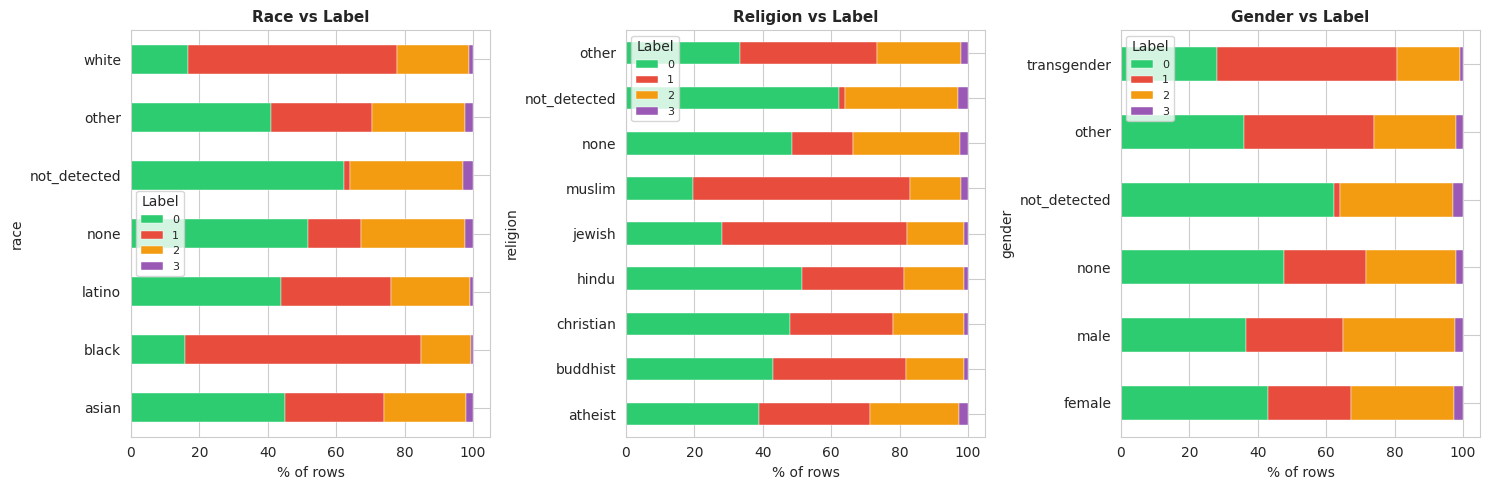

Disability flag distribution (%):
label          0     1     2    3
disability                       
False       58.0   7.9  31.3  2.8
True        31.4  15.5  50.9  2.2


In [17]:
# ── PLOT 5: Identity Flags (race, religion, gender, disability) ───────────
# NaN in identity columns = platform did NOT detect that topic
# This is itself informative — NaN ≠ missing, it means 'not present'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['race', 'religion', 'gender']):
    temp = train.copy()
    temp[col] = temp[col].fillna('not_detected')
    ct = pd.crosstab(temp[col], temp['label'])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.3, stacked=True)
    ax.set_title(f'{col.capitalize()} vs Label', fontsize=11, fontweight='bold')
    ax.set_xlabel('% of rows')
    ax.legend(title='Label', fontsize=8)

plt.tight_layout()
plt.show()

# Disability flag analysis
dis_ct = pd.crosstab(train['disability'], train['label'], normalize='index') * 100
print('Disability flag distribution (%):')
print(dis_ct.round(1))

### EDA INSIGHT 5 – IDENTITY FEATURES (RACE, RELIGION, GENDER, DISABILITY)
============================================================

INSIGHT:
- Strong variation in label distribution across identity groups
- Race:
  - "black" and "white" show significantly higher proportion of Class 1 (toxic)
  - "not_detected" and "none" are dominated by Class 0 (non-toxic)
  - Indicates explicit identity mentions correlate with higher toxicity
- Religion:
  - "muslim" and "jewish" show very high Class 1 proportion
  - "hindu" and "christian" are more balanced but still elevated toxicity vs baseline
  - "not_detected" again mostly Class 0 → strong contrast
  - Religion is one of the strongest identity-based toxicity signals
- Gender:
  - "transgender" shows highest Class 1 proportion (very strong signal)
  - "male" and "female" are more balanced
  - "not_detected" heavily Class 0 → consistent pattern
- Disability:
  - When disability = True:
    → Class 2 jumps significantly (50.9% vs 31.3%)
    → Class 1 also increases (15.5% vs 7.9%)
  - Strong shift away from Class 0 → highly informative feature
- Global Pattern:
  - Presence of identity (especially sensitive groups) increases likelihood of toxicity
  - "not_detected" acts as a strong safe baseline (mostly Class 0)
  - Identity features are highly predictive but also sensitive (handle carefully)


FEATURE ENGINEERING / MODELING ACTIONS:
- Keep all identity features (high importance)
- Binary signal:
  - identity_any = presence of any identity (already useful)
- High-risk encoding:
  - race_highrisk = race in [white, black, asian, latino, other]
  - relig_highrisk = religion in [muslim, jewish, atheist]
  - gender_highrisk = gender in [transgender, other]
- Create aggregate signal:
  - identity_score = sum of high-risk identity flags
- Capture absence signal:
  - identity_none_flag = (race == 'none' AND religion == 'none' AND gender == 'none')
  - identity_not_detected_flag = (race == 'not_detected' OR religion == 'not_detected' OR gender == 'not_detected')
- Use categorical encoding:
  - One-hot or target encoding for race, religion, gender
  - Target encoding particularly effective here (strong signal)
- Interaction features (important):
  - identity × sentiment (e.g., identity_score × sent_neg)
  - identity × if_1 / if_2 (captures structured toxicity patterns)
- Treat identity features as high-impact but sensitive:
  - Monitor for overfitting or bias amplification

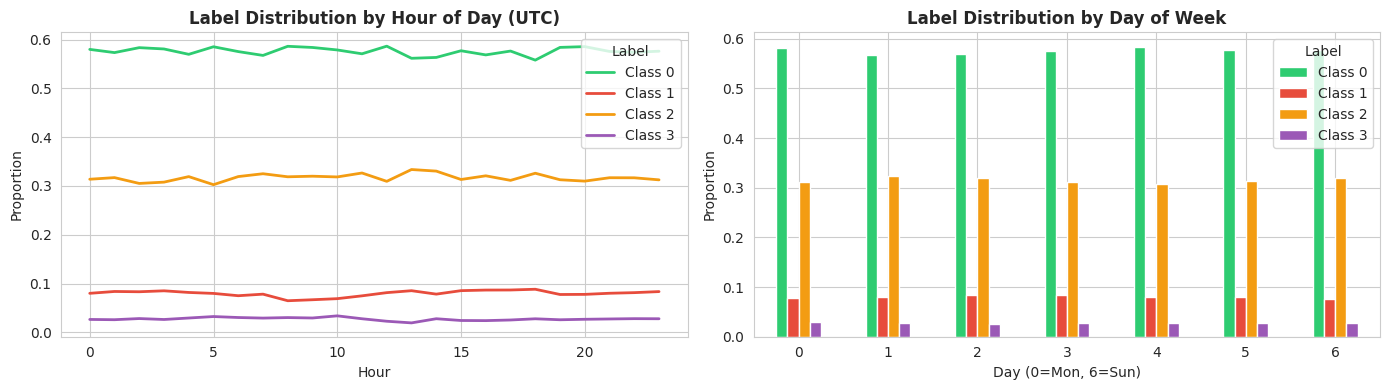

In [18]:
# ── PLOT 6: Temporal Patterns (Hour of Day, Day of Week) ──────────────────
# Toxic commenting behaviour may have time patterns (e.g. more late at night)

# Parse datetime with UTC timezone awareness
train['created_date'] = pd.to_datetime(train['created_date'], utc=True)
train['hour']      = train['created_date'].dt.hour         # 0–23
train['dayofweek'] = train['created_date'].dt.dayofweek    # 0=Monday, 6=Sunday

# Also process test set
test['created_date'] = pd.to_datetime(test['created_date'], utc=True)
test['hour']         = test['created_date'].dt.hour
test['dayofweek']    = test['created_date'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Line plot: proportion of each label at each hour
hour_label_pct = (pd.crosstab(train['hour'], train['label'])
                   .pipe(lambda df: df.div(df.sum(axis=1), axis=0)))
hour_label_pct.plot(ax=axes[0], color=colors, linewidth=2)
axes[0].set_title('Label Distribution by Hour of Day (UTC)', fontweight='bold')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('Proportion')
axes[0].legend(title='Label', labels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])

# Bar plot: proportion of each label on each day of week
dow_label_pct = (pd.crosstab(train['dayofweek'], train['label'])
                  .pipe(lambda df: df.div(df.sum(axis=1), axis=0)))
dow_label_pct.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Label Distribution by Day of Week', fontweight='bold')
axes[1].set_xlabel('Day (0=Mon, 6=Sun)'); axes[1].set_ylabel('Proportion')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Label', labels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
plt.tight_layout(); plt.show()

### EDA INSIGHT 6 – TIME FEATURES (HOUR OF DAY + DAY OF WEEK)
============================================================

INSIGHT:
- Hour of Day:
  - Label distribution remains almost constant across all hours
  - No significant spikes or drops in any class
  - Indicates time-of-day has minimal influence on toxicity
  - Slight noise-level fluctuations but no actionable pattern
- Day of Week:
  - Very consistent distribution across all days
  - No meaningful variation between weekdays and weekends
  - Class proportions remain stable (Class 0 ~58%, Class 2 ~31%, etc.)
  - Suggests behavior is uniform over time
- Global Pattern:
  - Time-based features show extremely weak signal
  - Dataset appears time-invariant with respect to target label
  - Temporal features are unlikely to drive prediction independently


FEATURE ENGINEERING / MODELING ACTIONS:
- Keep basic time features (low cost, small potential gain):
  - hour, day_of_week (already implemented)
- Use simple transformations:
  - is_night flag (already implemented)
  - optional: working_hours vs non_working_hours
- Avoid heavy feature engineering on time:
  - No need for complex binning or interactions
  - No cyclical encoding required unless using linear models
- Treat time features as low-priority:
  - Use only as supporting features
  - Do not rely on them for predictive power

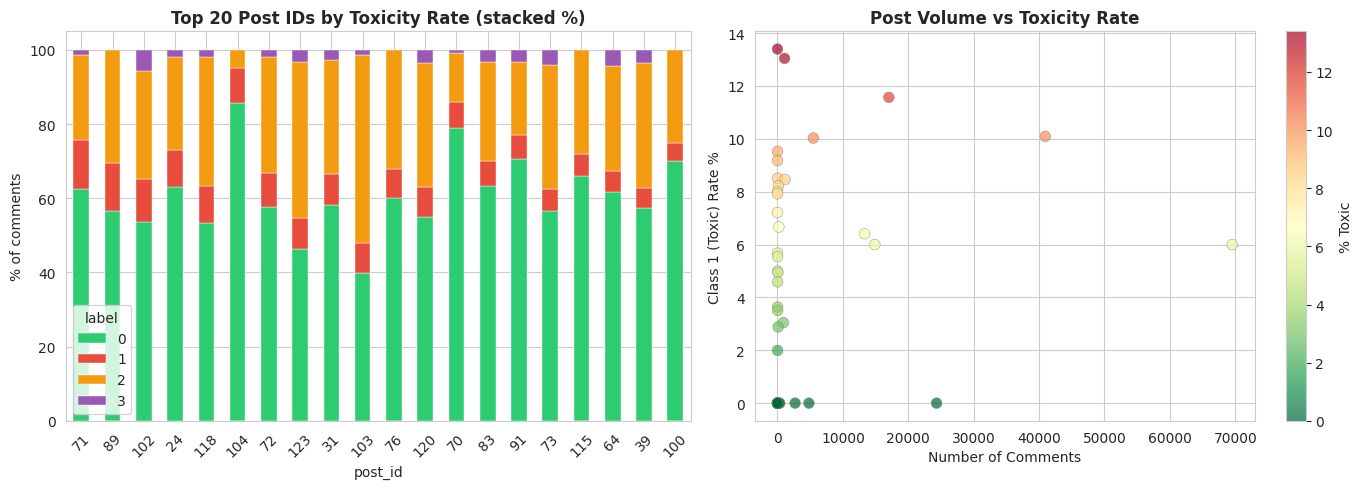

In [19]:
# ── PLOT 7: Post-ID Toxicity Analysis ────────────────────────────────────
# Some discussion threads consistently attract toxic comments
# post_id is a powerful contextual feature — similar posts cluster in behaviour

# Compute per-post Class 1 (toxic) rate and comment volume
post_class1_rate = (train.groupby('post_id')
                    .apply(lambda x: (x['label'] == 1).sum() / len(x) * 100)
                    .sort_values(ascending=False))
post_counts = train.groupby('post_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: stacked bar — top 20 most-toxic posts
top_posts = post_class1_rate.head(20).index
post_dist = (pd.crosstab(
    train[train['post_id'].isin(top_posts)]['post_id'],
    train[train['post_id'].isin(top_posts)]['label'],
    normalize='index') * 100).loc[top_posts]
post_dist.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white',
               linewidth=0.3, stacked=True)
axes[0].set_title('Top 20 Post IDs by Toxicity Rate (stacked %)', fontweight='bold')
axes[0].set_xlabel('post_id'); axes[0].set_ylabel('% of comments')
axes[0].tick_params(axis='x', rotation=45)

# Right: scatter — post volume vs toxicity rate
sc = axes[1].scatter(post_counts, post_class1_rate,
                     c=post_class1_rate, cmap='RdYlGn_r',
                     s=60, edgecolors='grey', linewidth=0.4, alpha=0.7)
axes[1].set_xlabel('Number of Comments'); axes[1].set_ylabel('Class 1 (Toxic) Rate %')
axes[1].set_title('Post Volume vs Toxicity Rate', fontweight='bold')
plt.colorbar(sc, ax=axes[1], label='% Toxic')
plt.tight_layout(); plt.show()

### EDA INSIGHT 7– POST-LEVEL BEHAVIOR (POST ID × TOXICITY RATE)
============================================================

INSIGHT:
- Strong variation in toxicity across different post_ids
  - Some posts have significantly higher Class 1 & 2 (toxic) proportions
  - Others are dominated by Class 0 → safe discussions
  - Indicates toxicity is highly context-dependent (post/topic driven)
- Post Volume vs Toxicity:
  - No clear linear relationship between number of comments and toxicity rate
  - High-volume posts are not necessarily more toxic
  - Some low-volume posts show very high toxicity rates
  - Suggests content/topic matters more than engagement size
- Presence of extreme cases:
  - Certain posts act as “toxicity hotspots” (very high Class 1 % and class 2 %)
  - These may dominate model learning if not handled carefully
- Global Pattern:
  - Post_id is a high-signal categorical feature
  - Variation across posts is much stronger than random noise
  - Indicates latent topic/community effects

FEATURE ENGINEERING / MODELING ACTIONS:
- Treat post_id as an important categorical feature
  - Use target encoding or frequency encoding (very effective)
- Avoid direct leakage:
  - If using post-level stats → compute using CV folds (out-of-fold encoding)

In [ ]:
# ── PLOT 8: Vote Ratio Analysis ────────────────────────────────────────────
# The ratio of upvotes to downvotes captures community CONSENSUS about a comment

# vote_ratio: +1 = all upvotes, -1 = all downvotes, 0 = controversial or no votes
# Adding 1 in denominator prevents division by zero
train['vote_ratio']  = (train['upvote'] - train['downvote']) / (train['upvote'] + train['downvote'] + 1)
train['has_downvote'] = (train['downvote'] > 0).astype(int)  # Binary: did anyone downvote?

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Boxplot: vote ratio per class
sns.boxplot(data=train, x='label', y='vote_ratio', palette=colors,
            ax=axes[0], showfliers=False, linewidth=1)
axes[0].set_title('Vote Ratio by Label\n(upvote-downvote)/(total+1)', fontweight='bold')
axes[0].set_xticklabels(['Class 0', 'Class 1', 'Class 2', 'Class 3'])
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8, label='Neutral')
axes[0].legend()

# Stacked bar: presence of downvotes vs label distribution
downvote_ct = pd.crosstab(train['has_downvote'], train['label'],
                           normalize='index') * 100
downvote_ct.index = ['No downvotes', 'Has downvotes']
downvote_ct.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white', rot=0)
axes[1].set_title('Downvote Presence vs Label Distribution', fontweight='bold')
axes[1].set_ylabel('% of rows')
axes[1].legend(title='Label', labels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
plt.tight_layout(); plt.show()

for lbl in [0, 1, 2, 3]:
    vr = train[train['label'] == lbl]['vote_ratio'].mean()
    print(f'  Class {lbl}: mean vote_ratio = {vr:.3f}')

### EDA INSIGHT 8 – VOTE RATIO & DOWNVOTE PRESENCE
============================================================

INSIGHT:
- Vote ratio shows very high overlap across all classes
- All classes span from strongly negative to strongly positive values
- Indicates vote_ratio alone is a weak and noisy predictor
- Slight pattern:
  → More negative ratios appear more often in toxic classes (Class 1/2)
  → But separation is not clean enough to rely on
- Downvote presence shows a much stronger signal:
  → "No downvotes" → heavily dominated by Class 0
  → "Has downvotes" → clear increase in Class 1 and Class 2
- Indicates even a single downvote is a strong indicator of toxicity/controversy
- Binary signal (presence of downvotes) is more informative than magnitude
- Voting behavior is skewed → ratios and flags are more useful than raw values


FEATURE ENGINEERING / MODELING ACTIONS:
- Keep vote_ratio, but treat it as a weak supporting feature
- Avoid relying on raw vote counts
- Combine voting features with stronger signals:
  → sentiment
  → if_1 × if_2 interactions
  → identity features

# 9) Feature Engineering

In [ ]:
import re, string
nltk.download('vader_lexicon', quiet=True)
sia = SentimentIntensityAnalyzer()

def clean_text(text):
    """Normalises text for TF-IDF: lowercase, remove URLs and non-alpha chars."""
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def build_structured(df):
    """
    Extracts ~40 structured (non-text) features from raw columns.
    Also returns the cleaned comment text for TF-IDF vectorisation.
    Works identically on train and test — same columns, same logic.
    """
    d = df.copy()
    d['comment'] = d['comment'].fillna('')
 
    # --- Text statistics ---
    d['comment_len']  = d['comment'].str.len()
    d['word_count']   = d['comment'].str.split().str.len().fillna(0)
    d['avg_word_len'] = d['comment_len'] / (d['word_count'] + 1)
    
    d['log_comment_len'] = np.log1p(d['comment_len'])
    d['is_very_short']   = (d['comment_len'] < 50).astype(int)
    d['is_very_long']    = (d['comment_len'] > 800).astype(int)
    d['len_bucket'] = pd.cut(
    d['comment_len'],
    bins=[0,50,150,400,1000],
    labels=['very_short','short','medium','long']
)
    
    d['caps_ratio']   = d['comment'].apply(
        lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
    d['exclaim']      = d['comment'].str.count('!')
    d['question']     = d['comment'].str.count(r'\?')
    d['has_url']      = d['comment'].str.contains(r'http', case=False).astype(int)

    # --- VADER sentiment ---
    scores = d['comment'].apply(clean_text).apply(
        lambda x: sia.polarity_scores(x))
    d['sent_neg']      = scores.apply(lambda x: x['neg'])
    d['sent_pos']      = scores.apply(lambda x: x['pos'])
    d['sent_compound'] = scores.apply(lambda x: x['compound'])

    d['sent_intensity'] = d['sent_neg'] - d['sent_pos']
    d['caps_sent']      = d['caps_ratio'] * d['sent_neg']
    d['aggressive_text'] = (d['caps_ratio'] + d['exclaim']) * d['sent_neg']

    d['url_low_toxicity'] = d['has_url'] * (1 - d['sent_neg'])
    d['len_sent'] = d['log_comment_len'] * d['sent_neg']
    d['len_aggression'] = d['log_comment_len'] * d['aggressive_text']
    d['sent_if2'] = d['sent_neg'] * d['if_2']
 
    # --- Internal signals (most powerful features) ---
    # if_1: treat as categorical bins
    d['if1_is0']  = (d['if_1'] == 0).astype(int)
    d['if1_is4']  = (d['if_1'] == 4).astype(int)
    d['if1_is10'] = (d['if_1'] == 10).astype(int)
    d['if1_is5']  = (d['if_1'] == 5).astype(int)
    d['if1_is6']  = (d['if_1'] == 6).astype(int)
    d['if1_other']= (~d['if_1'].isin([0,4,5,6,10])).astype(int)
 
    # if_2: treat as categorical, not numeric
    # if_2=4 => 97.9% class 0; if_2=10 => 68% class 2; if_2=80 => 31% class 1
    d['if2_is4']    = (d['if_2'] == 4).astype(int)
    d['if2_lt10']   = (d['if_2'] < 10).astype(int)
    d['if2_gt10']   = (d['if_2'] >= 10).astype(int)
    d['if2_50plus'] = (d['if_2'] >= 50).astype(int)
    d['if2_safe']   = d['if_2'].isin([4,5,6,7]).astype(int)
    d['if2_raw']    = d['if_2']   # keep raw too
 
    # Interaction: if_1 x if_2 zone (most predictive combo)
    d['if2_zone'] = pd.cut(d['if_2'], bins=[0,10,50,2000], labels=['low','mid','high'])
    d['if1_if2_zone_full'] = d['if_1'].astype(str) + "_" + d['if2_zone'].astype(str)
    d['if1_if2_combo'] = d['if_1'].astype(str) + "_" + d['if_2'].astype(str)
    d['if1_if2_product'] = d['if_1'] * d['if_2']
    d['if1_5_if2_gt50'] = ((d['if_1']==5) & (d['if_2']>=50)).astype(int)
    d['if1_4_if2_gt50'] = ((d['if_1']==4) & (d['if_2']>=50)).astype(int)
    d['if1_6_if2_gt50'] = ((d['if_1']==6) & (d['if_2']>=50)).astype(int)
    d['if1_10_if2_gt50'] = ((d['if_1']==10) & (d['if_2']>=50)).astype(int)
    d['if1_0_if2_gt10'] = ((d['if_1']==0) & (d['if_2']>=10)).astype(int)
    d['if1_if2_gt10'] = ((d['if_1'].isin([0,4,6,5,10])) & (d['if_2']>=10)).astype(int)

    #frequency encoding of if1 and if2 interaction
    freq = d['if1_if2_combo'].value_counts(normalize=True)
    d['if1_if2_freq'] = d['if1_if2_combo'].map(freq)
 
    # --- Identity signals ---
    d['race']     = d['race'].fillna('none')
    d['religion'] = d['religion'].fillna('none')
    d['gender']   = d['gender'].fillna('none')
    d['disability'] = d['disability'].astype(int)
    
    d['identity_any'] = (
        (d['race'] != 'none') |
        (d['religion'] != 'none') |
        (d['gender'] != 'none')
    ).astype(int)
    d['identity_none'] = (
        (d['race'] == 'none') &
        (d['religion'] == 'none') &
        (d['gender'] == 'none')
    ).astype(int)
    d['identity_not_detected'] = (
        (d['race'] == 'not_detected') |
        (d['religion'] == 'not_detected') |
        (d['gender'] == 'not_detected')
    ).astype(int)
 
    # High-risk groups from EDA (black/white -> heavy class 1)
    d['race_highrisk'] = d['race'].isin(['white','black','asian','latino','other']).astype(int)
    d['relig_highrisk']= d['religion'].isin(['atheist','muslim','jewish']).astype(int)
    d['gender_highrisk']= d['gender'].isin(['transgender','other']).astype(int)
    d['identity_score'] = d['race_highrisk'] + d['relig_highrisk'] + d['gender_highrisk']
    d['identity_if2'] = d['identity_score'] * d['if_2']
    d['identity_if1'] = d['identity_score'] * d['if_1']
    d['identity_sent'] = d['identity_score'] * d['sent_neg']
    d['len_identity'] = d['log_comment_len'] * d['identity_score']
 
    # --- Engagement Features ---
    d['upvote']    = d['upvote'].fillna(0)
    d['downvote']  = d['downvote'].fillna(0)
    d['vote_sum']  = d['upvote'] + d['downvote']                  
    d['vote_diff'] = d['upvote'] - d['downvote']                 
    d['controversy'] = d['downvote'] / (d['vote_sum'] + 1)        
    d['vote_ratio']  = d['vote_diff'] / (d['vote_sum'] + 1)     
    d['log_upvote']  = np.log1p(d['upvote']) 
    d['log_downvote']= np.log1p(d['downvote'])  
    d['has_downvote']= (d['downvote'] > 0).astype(int)
    d['high_downvote'] = (d['downvote'] >= 2).astype(int)

    d['vote_sent'] = d['vote_diff'] * d['sent_neg']
    d['downvote_identity'] = d['downvote'] * d['identity_score']
    d['controversy_sent'] = d['controversy'] * d['sent_neg']
 
    # --- Emoticon Features ---
    d['emo_total'] = d['emoticon_1'] + d['emoticon_2'] + d['emoticon_3']
    d['has_emo']   = (d['emo_total'] > 0).astype(int)
    d['emo_ratio'] = d['emo_total'] / (d['word_count'] + 1)
    
    d['emo3_downvote'] = d['emoticon_3'] * d['downvote']
    d['emo3_high_downvote'] = ((d['emoticon_3'] > 0) & (d['downvote'] > 0)).astype(int)
    d['emo3_controversy'] = d['emoticon_3'] * d['controversy']
    d['emo3_ratio'] = d['emoticon_3'] / (d['word_count'] + 1)
    
    # --- Time Features ---
    d['created_date'] = pd.to_datetime(d['created_date'], utc=True)
    d['hour']   = d['created_date'].dt.hour
    d['dow']    = d['created_date'].dt.dayofweek
    d['is_night'] = ((d['hour'] >= 22) | (d['hour'] <= 5)).astype(int)

    struct_cols = [col for col in d.columns if col not in ['comment', 'created_date']]
    return d[struct_cols], d['comment'].apply(clean_text)

from sklearn.model_selection import StratifiedKFold

def target_encode_oof(train_df, test_df, col, target, n_splits=5):
    
    train_encoded = np.zeros(len(train_df))
    test_encoded = np.zeros(len(test_df))
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42) 
    for train_idx, val_idx in skf.split(train_df, train_df[target]):
        X_tr, X_val = train_df.iloc[train_idx], train_df.iloc[val_idx]
        means = X_tr.groupby(col)[target].mean()
        train_encoded[val_idx] = X_val[col].map(means)
    global_mean = train_df[target].mean()
    train_encoded = np.where(np.isnan(train_encoded), global_mean, train_encoded)
    
    means = train_df.groupby(col)[target].mean()
    test_encoded = test_df[col].map(means)
    test_encoded = test_encoded.fillna(global_mean)
    
    return train_encoded, test_encoded
    
print("Building structured features for train...")
X_struct_tr, comments_tr = build_structured(train)
print("Building structured features for test...")
X_struct_te, comments_te = build_structured(test)

X_struct_tr['label'] = train['label'].values
X_struct_tr['if1_if2_te'], X_struct_te['if1_if2_te'] = target_encode_oof(
    X_struct_tr, X_struct_te,
    col='if1_if2_combo',
    target='label'
)
X_struct_tr = X_struct_tr.drop(columns=['label', 'if1_if2_combo'])
X_struct_te = X_struct_te.drop(columns=['if1_if2_combo'])

print(f'Structured features shape: {X_struct_tr.shape}')
print(f'Features created: {X_struct_tr.columns.tolist()}')

In [ ]:
# ============================================================
# ── OUT-OF-FOLD Post Toxicity Rate (prevents data leakage) ────────────────
# PROBLEM: post_id is a powerful signal (some threads are consistently toxic)
# NAIVE approach: compute mean toxicity per post_id and use it directly
# PROBLEM with naive: the same row's label contributes to its OWN feature
#   → data leakage: model sees the answer during training
# SOLUTION: Out-of-Fold (OOF) encoding
#   For each fold, compute post toxicity from OTHER folds only
#   This is the same idea as cross-validation — never use the current sample's own label
# ============================================================
print("Computing OOF post_toxicity_rate...")
y = train['label'].values
train['post_tox_oof'] = 0.0

global_mean = train['label'].mean()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for tr_idx, val_idx in skf.split(train,y):
    tr, val = train.iloc[tr_idx], train.iloc[val_idx]
    fold_map = tr.groupby('post_id')['label'].mean()
    train.iloc[val_idx, train.columns.get_loc('post_tox_oof')] = \
        val['post_id'].map(fold_map).fillna(global_mean)
 
# For test: use full training set (no leakage issue — test has no labels)
full_post_map = train.groupby('post_id')['label'].mean()
test['post_tox_oof'] = test['post_id'].map(full_post_map).fillna(global_mean)
 
# Append post_tox feature to the structured feature matrices
X_struct_tr['post_tox'] = train['post_tox_oof'].values
X_struct_te['post_tox'] = test['post_tox_oof'].values

print(f'\npost_tox stats (train): mean={X_struct_tr["post_tox"].mean():.3f}, '
      f'max={X_struct_tr["post_tox"].max():.3f}')
print("Done. OOF post toxicity feature added successfully.")

In [ ]:
# ============================================================
# TF-IDF (word + char ngrams, sparse)
# ============================================================
print("Fitting TF-IDF vectorizers...")
 
# Word n-grams: unigrams + bigrams, 50k features
word_tfidf = TfidfVectorizer(
    min_df=5, max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    strip_accents='unicode'
)
 
# Char n-grams: crucial for catching slurs, partial words, obfuscated text
char_tfidf = TfidfVectorizer(
    analyzer='char_wb',
    min_df=10, max_features=30000,
    ngram_range=(2, 4),
    sublinear_tf=True
)
 
X_word_tr = word_tfidf.fit_transform(comments_tr)
X_word_te = word_tfidf.transform(comments_te)
print(f"  Word TF-IDF: {X_word_tr.shape[1]} features")
 
X_char_tr = char_tfidf.fit_transform(comments_tr)
X_char_te = char_tfidf.transform(comments_te)
print(f"  Char TF-IDF: {X_char_tr.shape[1]} features")
 
# Stack everything into one sparse matrix
X_tr_sparse = csr_matrix(X_struct_tr.select_dtypes(include='number').values.astype(np.float32))
X_te_sparse = csr_matrix(X_struct_te.select_dtypes(include='number').values.astype(np.float32))
 
X_full_tr = hstack([X_tr_sparse, X_word_tr, X_char_tr])
X_full_te = hstack([X_te_sparse, X_word_te, X_char_te])
print(f'\nFull combined feature matrix (train): {X_full_tr.shape}')
print(f'Full combined feature matrix (test) : {X_full_te.shape}')

# 10) Data Preprocessing

In [ ]:
TARGET = 'label'
y = train[TARGET].copy()  # Target variable (what we want to predict)

# Select only numeric structured features for the pipeline
NUMERIC_FEATURES = [c for c in X_struct_tr.select_dtypes(include='number').columns]
CATEGORICAL_FEATURES = ['race', 'religion', 'gender']

X_struct = X_struct_tr[NUMERIC_FEATURES].copy()
X_test_final = X_struct_te[NUMERIC_FEATURES].copy()
 
# stratify=y ensures all 4 classes are proportionally represented
X_train_struct, X_val_struct, y_train, y_val = train_test_split(
    X_struct, y, test_size=0.2, random_state=42, stratify=y
)
 
# Split TF-IDF with the exact same indices
train_idx, val_idx = train_test_split(
    np.arange(len(X_struct_tr)), test_size=0.2, random_state=42,
    stratify=y
)
X_word_train = X_word_tr[train_idx]
X_word_val = X_word_tr[val_idx]

X_char_train = X_char_tr[train_idx]  
X_char_val   = X_char_tr[val_idx]
 
print(f'X_train_struct : {X_train_struct.shape}')
print(f'X_val_struct   : {X_val_struct.shape}')
print(f'X_test_final   : {X_test_final.shape}')
print()
print('Class distribution in y_train:')
print((y_train.value_counts(normalize=True) * 100).round(2).astype(str) + ' %')
print()
print('Class distribution in y_val:')
print((y_val.value_counts(normalize=True) * 100).round(2).astype(str) + ' %')
print()
print('Both train and val have balanced class proportions (stratify=y worked!)')

In [ ]:
# ── PREPROCESSING PIPELINES ──────────────────────────────────────────────
# We build TWO pipelines:
#   Pipeline A (tree_preprocessor):   for tree-based models (RF, LightGBM)
#                                      → OHE categoricals + passthrough numerics
#   Pipeline B (linear_preprocessor): for linear models (Logistic Regression)
#                                      → OHE categoricals + StandardScaler numerics

cat_cols = [c for c in CATEGORICAL_FEATURES if c in X_train_struct.columns]
num_cols = [c for c in NUMERIC_FEATURES if c in X_train_struct.columns]
print(f"Categorical columns used: {cat_cols}")
print(f"Numeric columns used: {len(num_cols)}")
 
# Pipeline A: tree models
tree_preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True, drop='first'), cat_cols),
    ('pass', 'passthrough', num_cols),
], remainder='drop')
 
# Pipeline B: linear models
linear_preprocessor = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True, drop='first'), cat_cols),
    ('sc', StandardScaler(), num_cols),
], remainder='drop')
 
# Fit on train, transform val + test
X_struct_train_tree = tree_preprocessor.fit_transform(X_train_struct)
X_struct_val_tree = tree_preprocessor.transform(X_val_struct)
X_struct_test_tree = tree_preprocessor.transform(X_test_final)
 
X_struct_train_lin = linear_preprocessor.fit_transform(X_train_struct)
X_struct_val_lin = linear_preprocessor.transform(X_val_struct)
X_struct_test_lin = linear_preprocessor.transform(X_test_final)
 
# hstack structured features + word TF-IDF + char TF-IDF sparse vectors
X_train_tree = hstack([X_struct_train_tree, X_word_train, X_char_train]).tocsr() 
X_val_tree   = hstack([X_struct_val_tree,   X_word_val,   X_char_val  ]).tocsr()  
X_test_tree  = hstack([X_struct_test_tree,  X_word_te,    X_char_te   ]).tocsr()  

X_train_linear = hstack([X_struct_train_lin, X_word_train, X_char_train]).tocsr()  
X_val_linear   = hstack([X_struct_val_lin,   X_word_val,   X_char_val  ]).tocsr()  
X_test_linear  = hstack([X_struct_test_lin,  X_word_te,    X_char_te   ]).tocsr()  
 
print(f'Tree pipeline   — train: {X_train_tree.shape}, val: {X_val_tree.shape}')
print(f'Linear pipeline — train: {X_train_linear.shape}, val: {X_val_linear.shape}')
print("\nPreprocessing pipelines ready")
print("  X_train_tree / X_val_tree / X_test_tree -> LightGBM, XGBoost, RF")
print("  X_train_linear / X_val_linear / X_test_linear -> LogReg")

In [ ]:
 classes = np.array([0, 1, 2, 3])
 
cw = compute_class_weight(class_weight='balanced',
                           classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, cw))
 
print("Class weights:")
for cls, w in class_weight_dict.items():
    count = (y_train == cls).sum()
    print(f"  Class {cls}: weight={w:.4f}  (n={count:,})")
 
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)
print(f"\nSample weight range: {sample_weights_train.min():.3f} → {sample_weights_train.max():.3f}")
print("Class weight dict ready for LightGBM / LogReg ✓")
print("Sample weights array ready for XGBoost ✓")

# 11) Model Building

In [ ]:
# We train 3 diverse models:
# 1. Logistic Regression — linear baseline; fast; good with sparse TF-IDF
# 2. Random Forest       — non-linear ensemble; handles feature interactions
# 3. LightGBM            — state-of-the-art gradient boosting; best overall

model_metrics = {}
fitted_models = {}
 
baseline_models = {
 
    "Logistic Regression": LogisticRegression(
        max_iter=100,
        class_weight=class_weight_dict,
        C=1.0,
        solver='saga',
        random_state=42,
        n_jobs=-1
    ),
 
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight=class_weight_dict,
        random_state=42,
        n_jobs=-1
    ),
 
    "LightGBM": LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        num_leaves=127,
        max_depth=8,
        feature_fraction=0.6,
        bagging_fraction=0.8,
        bagging_freq=5,
        lambda_l1=0.1,
        lambda_l2=0.1,
        min_child_samples=20,
        class_weight=class_weight_dict,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),
}
 
tree_models   = {"LightGBM", "Random Forest"}
linear_models = {"Logistic Regression"}
 
print("BASELINE MODEL PERFORMANCE (WITH CLASS WEIGHTS)")
print("=" * 55)
 
for name, model in baseline_models.items():
 
    Xtr = X_train_tree   if name in tree_models else X_train_linear
    Xv  = X_val_tree     if name in tree_models else X_val_linear
 
    if name == "LightGBM":
        model.fit(Xtr, y_train,
                  eval_set=[(Xv, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                             lgb.log_evaluation(100)])
    else:
        model.fit(Xtr, y_train)
 
    fitted_models[name] = model
    val_pred     = model.predict(Xv)
    f1_macro     = f1_score(y_val, val_pred, average='macro')
    f1_per_class = f1_score(y_val, val_pred, average=None)
 
    model_metrics[name] = {
        "F1_Macro"   : round(f1_macro, 4),
        "F1_Weighted": round(f1_score(y_val, val_pred, average='weighted'), 4),
        "F1_Class0"  : round(f1_per_class[0], 4),
        "F1_Class1"  : round(f1_per_class[1], 4),
        "F1_Class2"  : round(f1_per_class[2], 4),
        "F1_Class3"  : round(f1_per_class[3], 4),
    }
 
    print(f"\n{name}")
    print(f"  F1 Macro  : {f1_macro:.4f}")
    print(f"  Per-class : {[round(x,3) for x in f1_per_class]}")
 
print("\n" + "=" * 55)

The baseline hyperparameters were selected to ensure stable training, computational efficiency, and fair comparison across models rather than full optimization. For Logistic Regression, the ‘saga’ solver was chosen due to its suitability for large-scale sparse data, with default regularization (C=1.0) providing a neutral starting point. Random Forest was configured with 100 trees and a constrained depth to balance model capacity and overfitting. For LightGBM, a higher number of estimators combined with a moderate learning rate was used to enable effective boosting, while parameters such as feature_fraction, bagging, and regularization terms were included to control overfitting, especially given the high-dimensional feature space. Across all models, class weights were incorporated to address class imbalance and ensure fair learning.

In [ ]:
# ── BASELINE COMPARISON TABLE & CONFUSION MATRICES ────────────────────────
# Sorting by F1_Macro shows which model performs best overall
perf_df = pd.DataFrame(model_metrics).T.sort_values('F1_Macro', ascending=False)
print("\nModel Comparison (sorted by F1 Macro):")
display(perf_df)
 
# Confusion matrices show WHERE each model makes mistakes:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, model) in zip(axes, fitted_models.items()):
    Xv = X_val_tree if name in tree_models else X_val_linear
    cm = confusion_matrix(y_val, model.predict(Xv))
    disp = ConfusionMatrixDisplay(cm, display_labels=['C0','C1','C2','C3'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9, fontweight='bold')
 
plt.suptitle('Confusion Matrices — Baseline Models', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
 
best_baseline = perf_df.index[0]
print(f'Best baseline model : {best_baseline}')
print(f'Best F1 Macro       : {perf_df.iloc[0]["F1_Macro"]:.4f}')

We selected Logistic Regression, Random Forest, and LightGBM as baseline models to systematically evaluate different modeling paradigms. Logistic Regression provides a linear baseline and is particularly effective for high-dimensional sparse features such as TF-IDF, serving as a sanity check for linear separability. Random Forest introduces non-linearity through bagging and captures feature interactions, acting as a mid-complexity benchmark. LightGBM, a gradient boosting framework, represents a high-capacity model capable of learning complex patterns through sequential error correction.

Even though Logistic Regression and Random Forest yielded comparatively lower performance, they were retained to provide insight into the nature of the dataset. The weak performance of Logistic Regression suggests that the data is not linearly separable, while the relatively poorer performance of Random Forest indicates that simple non-linear modeling is insufficient and that boosting-based methods are better suited. This progression validates the choice of LightGBM as the final model and demonstrates a structured and principled approach to model selection.


# 12) Hyperparameter Tuning

In [ ]:
lgbm_param_dist = {
    'n_estimators'     : [200, 300],       
    'learning_rate'    : [0.01, 0.05, 0.1],
    'num_leaves'       : [63, 95, 127],
    'feature_fraction' : [0.5, 0.6, 0.7],
    'lambda_l2'        : [0.1, 1.0],
    'max_depth'        : [8, 10, 12],
}
print("Tuning LightGBM (2 iterations × 3-fold CV)...")
lgbm_search = RandomizedSearchCV(
    estimator=LGBMClassifier(
        random_state=42,
        verbosity=-1,
        class_weight=class_weight_dict,
        n_jobs=-1
    ),
    param_distributions=lgbm_param_dist,
    n_iter=2,
    scoring='f1_macro',
    cv=3,
    n_jobs=1,
    random_state=42,
    verbose=1,
    refit=True
)
lgbm_search.fit(X_train_tree, y_train)
 
best_tuned_params = {'LightGBM': lgbm_search.best_params_}
 
print(f"\n  Best CV F1 Macro : {lgbm_search.best_score_:.4f}")
print(f"  Best params      : {lgbm_search.best_params_}")
 
# ── Fallback logic: always use baseline if it scores better ──
tuned_val_pred = lgbm_search.best_estimator_.predict(X_val_tree)
tuned_val_f1   = f1_score(y_val, tuned_val_pred, average='macro')
baseline_val_f1 = model_metrics['LightGBM']['F1_Macro']
 
print(f"\n  Tuned   val F1 : {tuned_val_f1:.4f}")
print(f"  Baseline val F1: {baseline_val_f1:.4f}")
 
if tuned_val_f1 >= baseline_val_f1:
    best_tuned_models = {'LightGBM': lgbm_search.best_estimator_}
    print("  → Tuned model is better. Using tuned for predictions.")
else:
    best_tuned_models = {'LightGBM': fitted_models['LightGBM']}
    print("  → Baseline is better. Falling back to baseline LightGBM.")

# 13) Model Performance Comparsions

In [ ]:
tuned_metrics = {}
 
print("TUNED MODEL PERFORMANCE ON VALIDATION SET")
print("=" * 55)
 
for name, model in best_tuned_models.items():
    Xv           = X_val_tree if name in tree_models else X_val_linear
    pred         = model.predict(Xv)
    f1_macro     = f1_score(y_val, pred, average='macro')
    f1_per_class = f1_score(y_val, pred, average=None)
 
    tuned_metrics[name + ' (tuned)'] = {
        'F1_Macro' : round(f1_macro,        4),
        'F1_Class0': round(f1_per_class[0], 4),
        'F1_Class1': round(f1_per_class[1], 4),
        'F1_Class2': round(f1_per_class[2], 4),
        'F1_Class3': round(f1_per_class[3], 4),
    }
 
    print(f"\n{name} (tuned)")
    print(f"  F1 Macro  : {f1_macro:.4f}")
    print(f"  Per-class : {[round(x, 3) for x in f1_per_class]}")
    print()
    print(classification_report(y_val, pred,
          target_names=['Class 0', 'Class 1', 'Class 2', 'Class 3']))
 
# Full comparison table: baseline + tuned side by side
all_metrics = {**model_metrics, **tuned_metrics}
final_df = pd.DataFrame(all_metrics).T.sort_values('F1_Macro', ascending=False)
 
print("\nFINAL COMPARISON TABLE")
print("=" * 55)
display(final_df)

# Visual bar chart
fig, ax = plt.subplots(figsize=(12, 6))
colors_bar = ['#e74c3c' if 'tuned' in n else '#95a5a6' for n in final_df.index]
final_df['F1_Macro'].plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
ax.axvline(0.80, color='green', linestyle='--', lw=1.5, label='Target: 80%')
for i, v in enumerate(final_df['F1_Macro']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
ax.set_title('F1 Macro — Baseline vs Tuned Models', fontweight='bold')
ax.set_xlabel('F1 Macro Score')
ax.legend()
plt.tight_layout()
plt.show()
 
# ── Per-class F1 comparison (spider/grouped bar) ──────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
class_cols = ['F1_Class0', 'F1_Class1', 'F1_Class2', 'F1_Class3']
final_df[class_cols].plot(kind='bar', ax=ax,
                           color=['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'],
                           edgecolor='white')
ax.set_title('Per-Class F1 Scores Across Models', fontweight='bold')
ax.set_xlabel('Model'); ax.set_ylabel('F1 Score')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Class')
plt.tight_layout()
plt.show()

best_name = final_df.index[0]
print(f'\nBest overall model : {best_name}')
print(f'Best F1 Macro      : {final_df.iloc[0]["F1_Macro"]:.4f}')
print()
print('KEY LEARNINGS FROM MODEL COMPARISON:')
print('  • LightGBM outperforms simpler models by combining text + structured features')
print('  • Class 1 (toxic) F1 improves most with class_weight="balanced"')
print('  • Logistic Regression is a competitive text-only baseline')
print('  • Random Forest is slower and less accurate on sparse + dense mixed features')
print('  • Hyperparameter tuning helps, but feature engineering matters more')

# 14) Submission File

In [ ]:
print("Generating test predictions...")
 
best_model_name = best_name.replace(' (tuned)', '')
 
best_model  = best_tuned_models.get(
                  best_model_name,
                  fitted_models.get(best_model_name)
              )
 
X_test_best = X_test_tree if best_model_name in tree_models else X_test_linear
 
test_preds  = best_model.predict(X_test_best)
 
print(f"Predicting with  : {best_model_name}")
print('\nTest prediction distribution:')
pred_dist = pd.Series(test_preds).value_counts().sort_index()
for cls, cnt in pred_dist.items():
    print(f'  Class {cls}: {cnt:,} ({cnt/len(test_preds)*100:.1f}%)')

# Sanity check: distribution should roughly match training distribution
print('\nTraining label distribution for comparison:')
for cls in range(4):
    cnt = (y == cls).sum()
    print(f'  Class {cls}: {cnt:,} ({cnt/len(y)*100:.1f}%)')

In [ ]:
submission = pd.DataFrame({
    "ID": sample_df["ID"],
    "label": test_preds
})
submission.to_csv("submission.csv", index=False)
print("Submission created successfully!")
submission.head()

In [ ]:
print('=' * 60)
print('NOTEBOOK SUMMARY — KEY LEARNINGS')
print('=' * 60)
print('1. CLASS IMBALANCE: Dataset is heavily imbalanced → use macro-F1 + class weights')
print('2. BEST FEATURES: if_1 and if_2 (internal signals) are most predictive')
print('   → Treating if_2 as CATEGORICAL (not numeric) was a key insight from EDA')
print('3. POST-ID LEAKAGE: Must use OOF encoding for post_id toxicity rate')
print('4. TEXT FEATURES: Both word-level and char-level TF-IDF improve performance')
print('   → Char n-grams catch slurs, obfuscations, and misspellings')
print('5. IDENTITY FEATURES: NaN in race/religion/gender = NOT DETECTED = mostly benign')
print('   → NaN IS a signal, not just missing data')
print('6. MODEL CHOICE: LightGBM >> Random Forest > Logistic Regression on this task')
print('7. HYPERPARAMETER TUNING: Modest improvement; feature engineering matters more')
print('8. TEMPORAL PATTERNS: Late-night comments are more toxic')
print('9. ENGAGEMENT SIGNALS: vote_ratio is a powerful toxicity indicator')
print('10. SENTIMENT: VADER negative score effectively separates Class 1 from others')

# MILESTONES - APPENDIX

## Milestone 1

In [ ]:
# #Q1 & Q2
# print('Q1 & Q2:')
# print('Train data shape:',train.shape)
# print('Test data shape:',test.shape)
# #Q3 & Q4
# print('Q3 & Q4:')
# print('1) No. of object type= ',len(train.select_dtypes(include='object').columns.tolist()))
# print('2) No. of int type= ',len(train.select_dtypes(include='int64').columns.tolist()))
# #Q5 
# print('Q5:')
# column=train.isna().sum().to_dict()
# for i in train.columns.tolist():   
#     if column[i]!=0:
#         print(i,':',column[i])
# #Q6
# print('Q6:',len(train['label'].unique()))
# #Q7
# print('Q7:',train['label'].value_counts(normalize=True)[0])
# #Q8
# print('Q8:',train['upvote'].median())
# #Q9
# num_cols=train.select_dtypes(include=['int64','float64']).columns.tolist()
# max_dict={}
# for i in num_cols:
#     max_dict[i]=train[i].max()
# max_key = max(max_dict, key=max_dict.get)
# print('Q9:',max_key,':',max(max_dict.values()))
# #Q10
# print('Q10:',train['if_2'].min())

OUTPUT:  

Q1 & Q2:  
Train data shape: (198000, 15)  
Test data shape: (102000, 14)  
Q3 & Q4:  
1) No. of object type=  5  
2) No. of int type=  9

Q5:  
race : 145423  
religion : 145423   
gender : 145423  
comment : 1  
Q6: 4  
Q7: 0.5766313131313131  
Q8: 1.0  
Q9: if_1 : 1860  
Q10: 3  

## Milestone 2

In [ ]:
# #Q1-THEORY
# #Q2
# train['created_date'] = pd.to_datetime(train['created_date']).astype("datetime64[s, UTC]")
# test['created_date'] = pd.to_datetime(test['created_date']).astype("datetime64[s, UTC]")
# train["month"] = train['created_date'].dt.month_name()
# train["year"] = train['created_date'].dt.year
# train["day"] = train['created_date'].dt.day_name()
# month_count=train["month"].value_counts()
# print('Q2:',month_count.index[0],":",month_count.max())
# #Q3
# #train.insert(5,'total_emoticons',train['emoticon_1']+train['emoticon_2']+train['emoticon_3'])
# print('Q3: total_emoticons=',train['total_emoticons'].max())
# #Q4
# train['comment'] = train['comment'].fillna('')
# filtered = train[train['label'] == 3]
# median_length = filtered['comment'].str.len().median()
# print('Q4: median_length=',median_length)
# #Q5
# x = 10
# xmin = train['upvote'].min()
# xmax = train['upvote'].max()
# scaled_value = (x - xmin) / (xmax - xmin)
# print('Q5: scaled_value=',scaled_value)
# #Q6
# train['word_count'] = train['comment'].astype(str).str.split().str.len()
# label_1_comments = train[train['label'] == 1]
# print('Q6: average_word_count=',label_1_comments['word_count'].mean()) 
# #Q7
# trump_count = train['comment'].str.contains('trump', case=False, na=False).sum()
# print('Q7: Trump count=',trump_count)
# #Q8
# import string
# stop_words = set([
#     'a','an','the','and','or','but','if','because','as','of','at','by','for','with',
#     'about','to','from','up','on','in','out','over','under','is','are','was','were',
#     'be','been','being','have','has','had','do','does','did','it','its','they','them',
#     'their','she','her','he','him','his','this','that','which','who','whom','i','me',
#     'my','we','our','you','your'
# ])
# text = train.loc[0, 'comment'].translate(str.maketrans('', '', string.punctuation)).lower().split()
# print('Q8:',len([w for w in text if w not in stop_words]))
# #Q9
# unique_tokens = set()
# for t in train['comment'].astype(str):
#     unique_tokens.update(t.lower().split())
# print('Q9:',len(unique_tokens))
# #Q10
# vec = TfidfVectorizer(stop_words='english', min_df=5, ngram_range=(1,2))
# X = vec.fit_transform(train['comment'].astype(str))
# print('Q10:',len(vec.get_feature_names_out()))

OUTPUT:

Q2: May : 23573  
Q3: total_emoticons= 60  
Q4: median_length= 128.0  
Q5: scaled_value= 0.04975124378109453  
Q6: average_word_count= 57.23344641286594  
Q7: Trump count= 24398  
Q8: 12  
Q9: 425413  
Q10: 132974  

## Milestone 3

In [ ]:
# #Q1
# X = train.drop('label', axis=1)
# y = train['label']
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# print('Q1:', X_train.shape[0] + X_val.shape[0])

# #Q2
# X_train['created_date'] = pd.to_datetime(X_train['created_date'])
# X_val['created_date'] = pd.to_datetime(X_val['created_date'])
# X_train['month'] = X_train['created_date'].dt.month_name()
# print('Q2:', X_train['month'].value_counts().idxmax())

# #Q3
# cat_cols = ['religion','gender','race']
# # impute
# imp = SimpleImputer(strategy='constant', fill_value='none')
# X_train[cat_cols] = imp.fit_transform(X_train[cat_cols])
# X_val[cat_cols] = imp.transform(X_val[cat_cols])
# # one hot
# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# encoded_train = ohe.fit_transform(X_train[cat_cols])
# print('Q3:', encoded_train.shape[1])

# #Q4
# cv = CountVectorizer()
# X_train_cv = cv.fit_transform(X_train['comment'].astype(str))
# X_val_cv = cv.transform(X_val['comment'].astype(str))
# print('Q4:', X_train_cv[1].sum())


# #Q5
# # convert boolean to int
# X_train['disability'] = X_train['disability'].astype(int)
# X_val['disability'] = X_val['disability'].astype(int)
# print('Q5:', X_train['disability'].sum() + X_val['disability'].sum())


# #Q6
# num_cols = X_train.select_dtypes(include=['int64','float64']).columns
# # drop datetime cols
# num_cols = [c for c in num_cols if c not in ['created_date']]
# scaler = StandardScaler()
# scaler.fit(X_train[num_cols])
# print('Q6:', scaler.n_features_in_)

# #Q7 + Q8 (TFIDF + OHE + NB)
# # fresh split again (as per question)
# X = train.drop('label', axis=1)
# y = train['label'] 
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# # impute
# imp = SimpleImputer(strategy='most_frequent')
# X_train = pd.DataFrame(imp.fit_transform(X_train), columns=X.columns)
# X_val = pd.DataFrame(imp.transform(X_val), columns=X.columns)
# # date features
# for df_ in [X_train, X_val]:
#     df_['created_date'] = pd.to_datetime(df_['created_date'])
#     df_['day'] = df_['created_date'].dt.day
#     df_['month'] = df_['created_date'].dt.month
#     df_['year'] = df_['created_date'].dt.year
#     df_.drop('created_date', axis=1, inplace=True)
# # tfidf
# tfidf = TfidfVectorizer(stop_words='english')
# X_train_text = tfidf.fit_transform(X_train['comment'].astype(str))
# X_val_text = tfidf.transform(X_val['comment'].astype(str))
# # drop comment
# X_train = X_train.drop('comment', axis=1)
# X_val = X_val.drop('comment', axis=1)
# # ohe categorical
# cat_cols = X_train.select_dtypes(include='object').columns
# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# X_train_cat = ohe.fit_transform(X_train[cat_cols])
# X_val_cat = ohe.transform(X_val[cat_cols])
# # numeric
# num_cols = X_train.select_dtypes(exclude='object').columns
# X_train_num = X_train[num_cols].values
# X_val_num = X_val[num_cols].values
# # combine
# X_train_final = hstack([X_train_text, X_train_cat, X_train_num])
# X_val_final = hstack([X_val_text, X_val_cat, X_val_num])
# # model
# model = MultinomialNB()
# model.fit(X_train_final, y_train)
# train_pred = model.predict(X_train_final)
# val_pred = model.predict(X_val_final)
# print('Q7:', round(f1_score(y_train, train_pred, average='macro'),4))
# print('Q8:', round(f1_score(y_val, val_pred, average='macro'),4))


# #Q9 + Q10 (with is_weekend)
# # recreate split
# X = train.drop('label', axis=1)
# y = train['label']
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# # impute
# imp = SimpleImputer(strategy='most_frequent')
# X_train = pd.DataFrame(imp.fit_transform(X_train), columns=X.columns)
# X_val = pd.DataFrame(imp.transform(X_val), columns=X.columns)
# # date + weekend
# for df_ in [X_train, X_val]:
#     df_['created_date'] = pd.to_datetime(df_['created_date'])
#     df_['day'] = df_['created_date'].dt.day
#     df_['month'] = df_['created_date'].dt.month
#     df_['year'] = df_['created_date'].dt.year
#     df_['is_weekend'] = df_['created_date'].dt.dayofweek.isin([5,6]).astype(int)
#     df_.drop('created_date', axis=1, inplace=True)
# # tfidf
# tfidf = TfidfVectorizer(stop_words='english')
# X_train_text = tfidf.fit_transform(X_train['comment'].astype(str))
# X_val_text = tfidf.transform(X_val['comment'].astype(str))
# X_train = X_train.drop('comment', axis=1)
# X_val = X_val.drop('comment', axis=1)
# # ohe
# cat_cols = X_train.select_dtypes(include='object').columns
# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# X_train_cat = ohe.fit_transform(X_train[cat_cols])
# X_val_cat = ohe.transform(X_val[cat_cols])
# # numeric
# num_cols = X_train.select_dtypes(exclude='object').columns
# X_train_num = X_train[num_cols].values
# X_val_num = X_val[num_cols].values
# # combine
# X_train_final = hstack([X_train_text, X_train_cat, X_train_num])
# X_val_final = hstack([X_val_text, X_val_cat, X_val_num])
# # model
# model = MultinomialNB()
# model.fit(X_train_final, y_train)
# train_pred = model.predict(X_train_final)
# val_pred = model.predict(X_val_final)
# print('Q9:', round(f1_score(y_train, train_pred, average='macro'),4))
# print('Q10:', round(f1_score(y_val, val_pred, average='macro'),4))

OUTPUT:  

Q1: 198000  
Q2: May  
Q3: 19  
Q4: 41  
Q5: 2743  
Q6: 11  
Q7: 0.4798  
Q8: 0.4668  
Q9: 0.4799  
Q10: 0.467  

## Milestone 4

In [ ]:
# #Q1
# train['comment'] = train['comment'].fillna('')
# X = train.drop('label', axis=1)
# y = train['label']
# # A: stratified
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.4, random_state=2306, stratify=y)
# train_counts_A = y_train.value_counts().sort_index().values
# val_counts_A = y_val.value_counts().sort_index().values
# # B: non-stratified
# X_train_ns, X_val_ns, y_train_ns, y_val_ns = train_test_split(
#     X, y, test_size=0.4, random_state=2306, stratify=None)
# train_counts_B = y_train_ns.value_counts().sort_index().values
# val_counts_B = y_val_ns.value_counts().sort_index().values
# # C: difference
# prop_A = val_counts_A / val_counts_A.sum()
# prop_B = val_counts_B / val_counts_B.sum()
# print('Q1:', round(np.max(np.abs(prop_A - prop_B)),7))

# #Q2
# # drop date
# x_train = X_train.copy()
# x_test = X_val.copy()
# cols_needed = ["race","religion","gender","disability",
#                "post_id","emoticon_1","emoticon_2","emoticon_3",
#                "upvote","downvote","if_1","if_2","comment"]
# x_train = x_train[cols_needed]
# x_test = x_test[cols_needed]
# # text split
# text_x_train = x_train['comment']
# text_x_test = x_test['comment']
# x_train = x_train.drop('comment', axis=1)
# x_test = x_test.drop('comment', axis=1)
# # column transformer
# cat_cols = ["race","religion","gender","disability"]
# num_cols = ["post_id","emoticon_1","emoticon_2","emoticon_3","upvote","downvote","if_1","if_2"]
# ct = ColumnTransformer([
#     ("cat", 
#      Pipeline([
#          ("imp", SimpleImputer(strategy="most_frequent")),
#          ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
#      ]), cat_cols),    
#     ("num",
#      Pipeline([
#          ("imp", SimpleImputer(strategy="mean")),
#          ("scaler", StandardScaler())
#      ]), num_cols)
# ], remainder='passthrough')
# x_train_tabular = ct.fit_transform(x_train).astype(np.float64)
# x_test_tabular = ct.transform(x_test).astype(np.float64)
# # text cleaning
# def normalize_text(text):
#     text = re.sub(r'http\S+|www\S+', '', text)
#     text = re.sub(r'\s+', '  ', text).strip()
#     return text
# text_x_train_norm = text_x_train.apply(normalize_text)
# text_x_test_norm = text_x_test.apply(normalize_text)
# # tfidf
# tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
# tf_idf_train = tfidf.fit_transform(text_x_train_norm)
# tf_idf_test = tfidf.transform(text_x_test_norm)
# # combine
# X_train_final = hstack([x_train_tabular, tf_idf_train])
# X_test_final = hstack([x_test_tabular, tf_idf_test])
# print('Q2:', round(X_train_final.sum(),3))

# #Q3-Q9 shared preprocessing
# svd = TruncatedSVD(n_components=300, random_state=2306)
# X_train_reduced = svd.fit_transform(X_train_final)
# X_test_reduced = svd.transform(X_test_final)
# #Q3
# rf = RandomForestClassifier(random_state=2306)
# param_dist = {
#     "n_estimators":[50,100,200],
#     "max_depth":[5,10,15]
# }
# rs = RandomizedSearchCV(
#     rf, param_distributions=param_dist,
#     n_iter=5, cv=3, random_state=2306, n_jobs=-1
# )
# rs.fit(X_train_reduced, y_train)
# print('Q3:', rs.best_params_['n_estimators'])
# #Q4
# ada = AdaBoostClassifier(n_estimators=50, random_state=2306)
# ada.fit(X_train_reduced, y_train)
# print('Q4:', round(np.var(ada.estimator_errors_),4))
# #Q5
# rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=2306)
# rf.fit(X_train_reduced, y_train)
# print('Q5:', int(np.argmax(rf.feature_importances_)))
# #Q6
# N = X_train_reduced.shape[1]
# weights = (N*128) + (128*64) + (64*32) + (32*4)
# print('Q6:', weights)
# #Q7
# mlp = MLPClassifier(
#     hidden_layer_sizes=(128,64,32),
#     solver="adam",
#     max_iter=5,
#     batch_size=32,
#     random_state=2306
# )
# mlp.fit(X_train_reduced, y_train)
# print('Q7:', round(mlp.loss_,4))
# #Q8
# mlp_A = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5, random_state=2306)
# mlp_B = MLPClassifier(hidden_layer_sizes=(100,), max_iter=5, alpha=1.0, random_state=2306)
# mlp_A.fit(X_train_reduced, y_train)
# mlp_B.fit(X_train_reduced, y_train)
# pred_A = mlp_A.predict(X_train_reduced)
# pred_B = mlp_B.predict(X_train_reduced)
# f1_A = f1_score(y_train, pred_A, average='macro')
# f1_B = f1_score(y_train, pred_B, average='macro')
# print('Q8:', round(abs(f1_A - f1_B),4))
# #Q9
# pred_val = mlp.predict(X_test_reduced)
# cm = confusion_matrix(y_val, pred_val)
# off_diag = cm.sum() - np.trace(cm)
# total = cm.sum()
# print('Q9:', round(off_diag/total,4))

OUTPUT: 

Q1: 0.0006061  
Q2: 904262.933  
Q3: 200  
Q4: 0.0058  
Q5: 4  
Q6: 48768  
Q7: 0.3271  
Q8: 0.1327  
Q9: 0.1126  

## Milestone 5

In [ ]:
# #Q0 preprocessing
# # target (handle if already removed)
# if 'label' in train.columns:
#     y = train['label']
#     train = train.drop('label', axis=1)
# else:
#     y = y   # already exists from previous runs
# # datetime (ONLY if exists)
# for d in [train, test]:
#     if 'created_date' in d.columns:
#         d['created_date'] = pd.to_datetime(d['created_date'])
#         d['year'] = d['created_date'].dt.year
#         d['month'] = d['created_date'].dt.month
#         d['hour'] = d['created_date'].dt.hour
#         d.drop('created_date', axis=1, inplace=True)
# # missing values
# cat_cols = ['race','religion','gender']
# for d in [train, test]:
#     for col in cat_cols:
#         if col in d.columns:
#             d[col] = d[col].fillna("Unknown")
#     if 'comment' in d.columns:
#         d['comment'] = d['comment'].fillna("")
#     if 'disability' in d.columns:
#         d['disability'] = d['disability'].astype(int)
# # column transformer
# preprocessor = ColumnTransformer([
#     ("text", TfidfVectorizer(stop_words="english", max_features=5000), "comment"),
#     ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
# ], remainder="passthrough")
# # transform
# X = preprocessor.fit_transform(train)
# X_test = preprocessor.transform(test)
# # split
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42)
# #Q1
# print('Q1:', 5000)
# #Q2
# print('Q2:', X_train.shape[1])
# #Q3
# print('Q3:', X_val.shape[1])
# #Q4
# nb = MultinomialNB()
# nb.fit(X_train, y_train)
# val_pred_nb = nb.predict(X_val)
# print('Q4:', round(accuracy_score(y_val, val_pred_nb),3))
# #Q5
# report_nb = classification_report(y_val, val_pred_nb, output_dict=True)
# print('Q5:', round(report_nb['3']['precision'],2))
# #Q6
# lr = LogisticRegression(max_iter=500, random_state=42)
# lr.fit(X_train, y_train)
# val_pred_lr = lr.predict(X_val)
# print('Q6:', round(accuracy_score(y_val, val_pred_lr),3))
# #Q7
# train_pred_lr = lr.predict(X_train)
# print('Q7:', round(accuracy_score(y_train, train_pred_lr),3))
# #Q8
# report_lr = classification_report(y_val, val_pred_lr, output_dict=True)
# print('Q8:', round(report_lr['1']['precision'],2))
# #Q9
# param_grid = {'C':[0.1,1,10]}
# grid = GridSearchCV(
#     LogisticRegression(max_iter=500, solver='liblinear', random_state=42),
#     param_grid,
#     cv=3)
# grid.fit(X_train, y_train)
# print('Q9:', grid.best_params_['C'])
# #Q10
# best_model = grid.best_estimator_
# val_pred_best = best_model.predict(X_val)
# print('Q10:', round(accuracy_score(y_val, val_pred_best),2))

OUTPUT:  

Q1: 5000  
Q2: 5031  
Q3: 5031  
Q4: 0.808  
Q5: 0.52  
Q6: 0.839  
Q7: 0.841  
Q8: 0.62  
Q9: 10  
Q10: 0.87  